In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [30]:
# Load the dataset
train_encoded = pd.read_csv('encoded_data/train_encoded.csv')
test_encoded = pd.read_csv('encoded_data/test_encoded.csv')

# Prepare X and y for modeling
X = train_encoded.drop(['id', 'accident_risk'], axis=1)
y = train_encoded['accident_risk']
# Prepare test data
X_test = test_encoded.drop(['id','accident_risk'], axis=1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")


X shape: (517754, 17)
y shape: (517754,)
X_test shape: (172585, 17)


In [31]:
# Split data for training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (414203, 17)
X_val shape: (103551, 17)


In [38]:
#function to evaluate model performance
def evaluate_model(model, X_train, y_train, X_val, y_val):
    
    #train model
    model.fit(X_train, y_train)

    #make predictions
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    #calculate RMSE
    train_rmse = np.sqrt(np.mean((y_train - train_preds) ** 2))
    val_rmse = np.sqrt(np.mean((y_val - val_preds) ** 2))

    return train_rmse, val_rmse

In [40]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    train_rmse, val_rmse = evaluate_model(model, X_train, y_train, X_val, y_val)
    results[name] = {'Train RMSE': train_rmse, 'Validation RMSE': val_rmse}
    print(f"{name} - Train RMSE: {train_rmse:.4f}, Validation RMSE: {val_rmse:.4f}")
    print("-" * 40)

Training Linear Regression...
Linear Regression - Train RMSE: 0.0735, Validation RMSE: 0.0735
----------------------------------------
Training Decision Tree...


/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

Decision Tree - Train RMSE: 0.0073, Validation RMSE: 0.0830
----------------------------------------
Training Random Forest...
Random Forest - Train RMSE: 0.0230, Validation RMSE: 0.0597
----------------------------------------
Training XGBoost...
XGBoost - Train RMSE: 0.0553, Validation RMSE: 0.0564
----------------------------------------


<Figure size 1200x800 with 0 Axes>

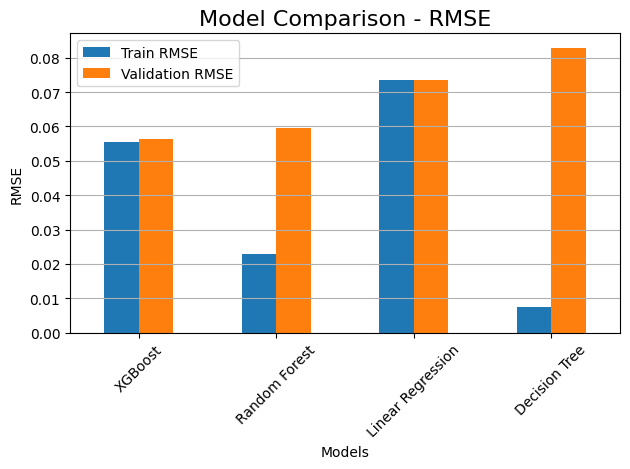

                   Train RMSE  Validation RMSE
XGBoost              0.055341         0.056383
Random Forest        0.023007         0.059685
Linear Regression    0.073484         0.073529
Decision Tree        0.007305         0.082973


In [41]:
# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Validation RMSE')

# Plot results
plt.figure(figsize=(12, 8))
results_df.plot(kind='bar')
plt.title('Model Comparison - RMSE', fontsize=16)
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(results_df)

In [50]:
#XGBoost wins with the lowest validation RMSE, lets tune it

#Define GridSearch parameter grid
param_grid = {
    'n_estimators': [100, 200, 250, 300],
    'max_depth': [3, 5, 6,7,8],
    'learning_rate': [0.01, 0.05,0.075, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0,1.2],
    'min_child_weight': [1, 3,4,5],
    'gamma': [0, 0.1, 0.2, 0.3]
}

In [52]:
# We are going to save a bit of computation time by using RandomizedSearchCV instead of GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

xgb_mdoel = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_mdoel,
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv= 5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_mdoel,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.075, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   3.8s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.075, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.075, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   4.2s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.075, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   4.2s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.075, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   4.2s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=250, subsample=1.0; total time=   7.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=

/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/aleksandergornik/Projects/Predicting-Road-Accident-Risk/.venv/lib/python3.9/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/Users/aleksandergornik

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          num_parallel_tree=None,
                                          random_state=42, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0,
                                                             1.2],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.075,
                                                          0.1],
                                        'max_depth': [3, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 4, 5],
                                        'n_estimators': [100, 200, 250, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [53]:
#get best model
print("Best parameters found: ", random_search.best_params_)
print("Best RMSE found: ", -random_search.best_score_)

#Evaluate best model on validation set
best_model = random_search.best_estimator_
val_preds = best_model.predict(X_val)
val_rmse = np.sqrt(np.mean((y_val - val_preds) ** 2))
print(f"Validation RMSE of best model: {val_rmse:.4f}")

Best parameters found:  {'subsample': 0.7, 'n_estimators': 250, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.075, 'gamma': 0, 'colsample_bytree': 1.0}
Best RMSE found:  0.05612750907771054
Validation RMSE of best model: 0.0563


/var/folders/6x/ffk1ml0n4xg1h9xcjg_gk_pc0000gn/T/ipykernel_23742/3447691583.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


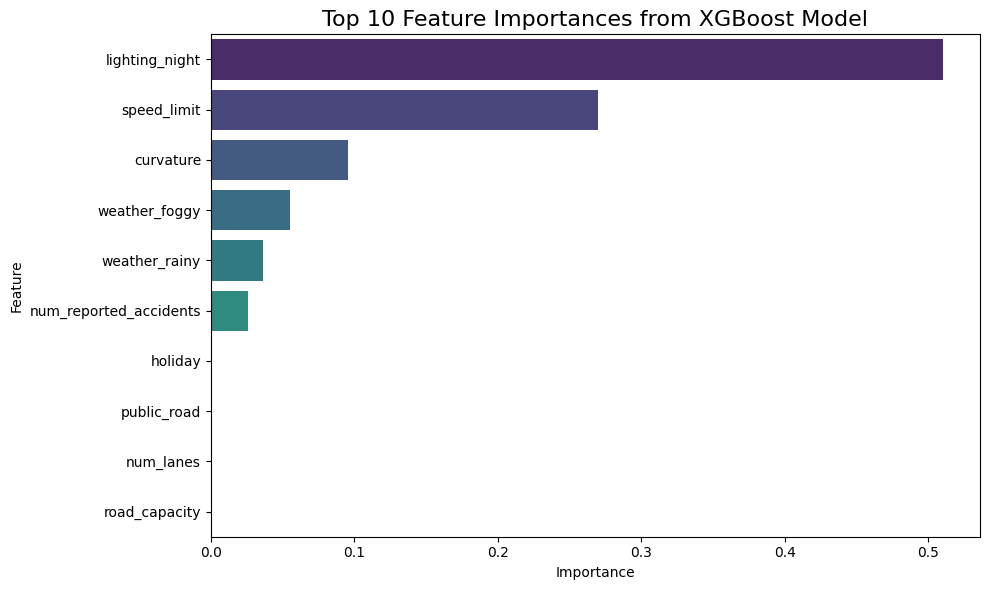

In [54]:
#plot feature importance
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Top 10 Feature Importances from XGBoost Model', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [56]:
#make predictions 
xgb_preds = best_model.predict(X_test)

submission = pd.DataFrame({
    'id': test_encoded['id'],
    'accident_risk': xgb_preds
})

print(submission.head())

#save to CSV
submission.to_csv('playground-series-data/xgboost_submission.csv', index=False)


       id  accident_risk
0  517754       0.290774
1  517755       0.119608
2  517756       0.184841
3  517757       0.323365
4  517758       0.407583
